In [3]:
from speclite import filters

import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroplan import Observer
import pytz

import seaborn as sns
import pandas as pd
from astropy.coordinates import AltAz
from datetime import datetime, timedelta
from astropy.time import TimezoneInfo


from astropy.coordinates import get_body
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

import matplotlib.patches  # make sure this is imported at the top

sns.set_theme("paper", style="white")

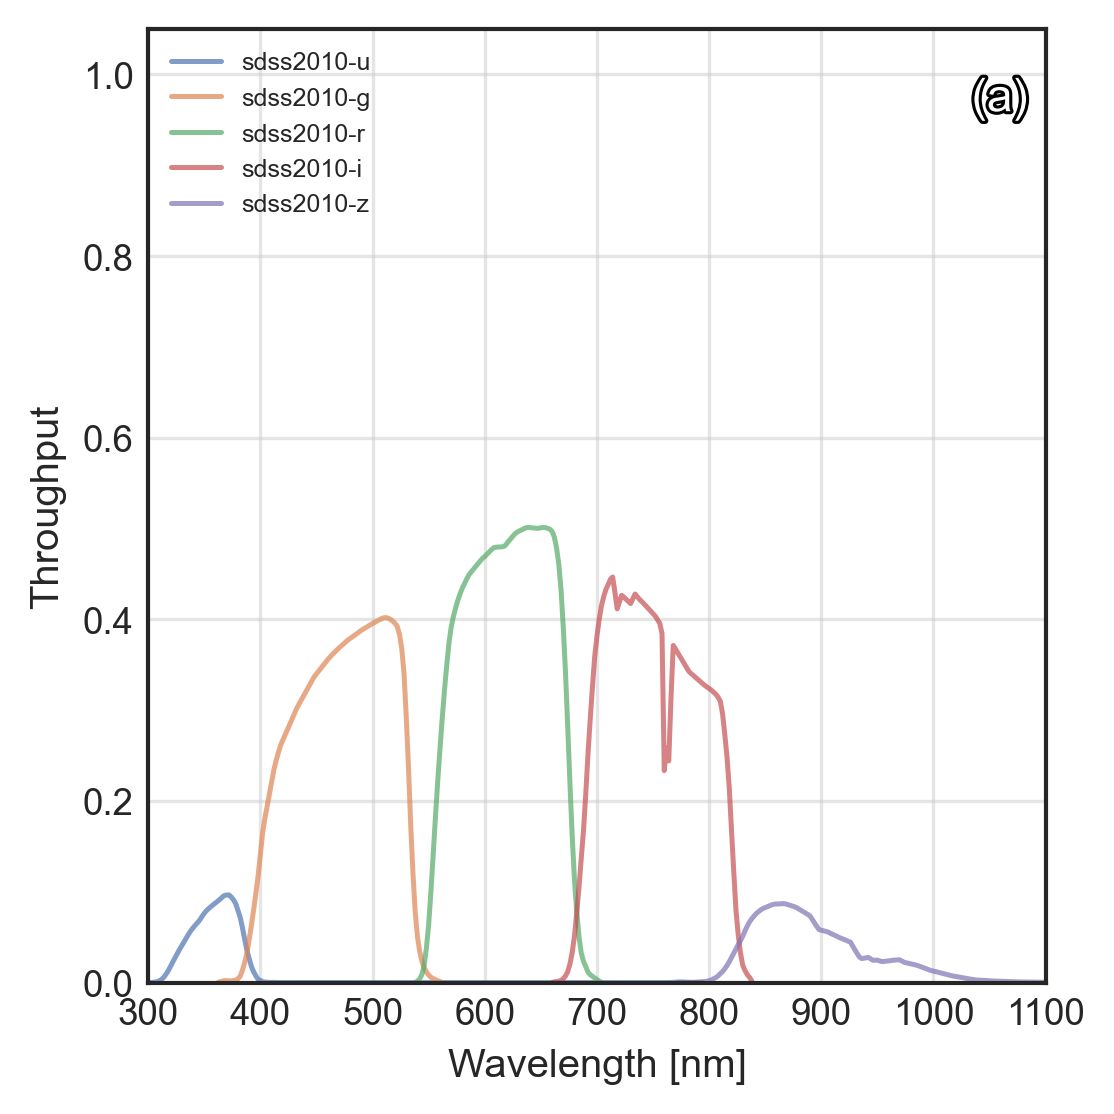

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
from speclite import filters

# Load SDSS filters
sdss = filters.load_filters('sdss2010-*')

# Wavelength limits in nm
wavelength_limits = (300, 1100)

# Create figure
fig, ax = plt.subplots(figsize=(3.6, 3.6), dpi=300, constrained_layout=True)

# Plot each filter individually
for f in sdss:
    # Convert wavelength from Angstroms to nm
    wave_nm = f.wavelength / 10.0
    # Get throughput by calling the filter on its wavelength array
    throughput = f(f.wavelength)
    ax.plot(
        wave_nm,
        throughput,
        lw=1.2,
        alpha=0.7,
        label=f.name
    )

# Axis limits and labels
ax.set_xlim(*wavelength_limits)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Throughput")

# Styling: grid, ticks, minor ticks
ax.tick_params(axis='both', which='both', length=0)
ax.minorticks_on()
ax.grid(True)

# Annotation
txt = ax.text(0.98, 0.95, "(a)", transform=ax.transAxes,
              fontsize=11, va="top", ha="right", color="white")
txt.set_path_effects([patheffects.withStroke(linewidth=1.5, foreground='black')])

# Optional legend
ax.legend(fontsize=6, frameon=False)

# Save figure
plt.savefig("plots/sdss_filters.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
latitude = 51.84257
longitude = 5.83896
elevation = 60  # meters
timezone = pytz.timezone("Europe/Amsterdam")

observer = Observer(latitude=latitude * u.deg,
                    longitude=longitude * u.deg,
                    elevation=elevation * u.m,
                    timezone="Europe/Amsterdam",
                    name="Nijmegen")


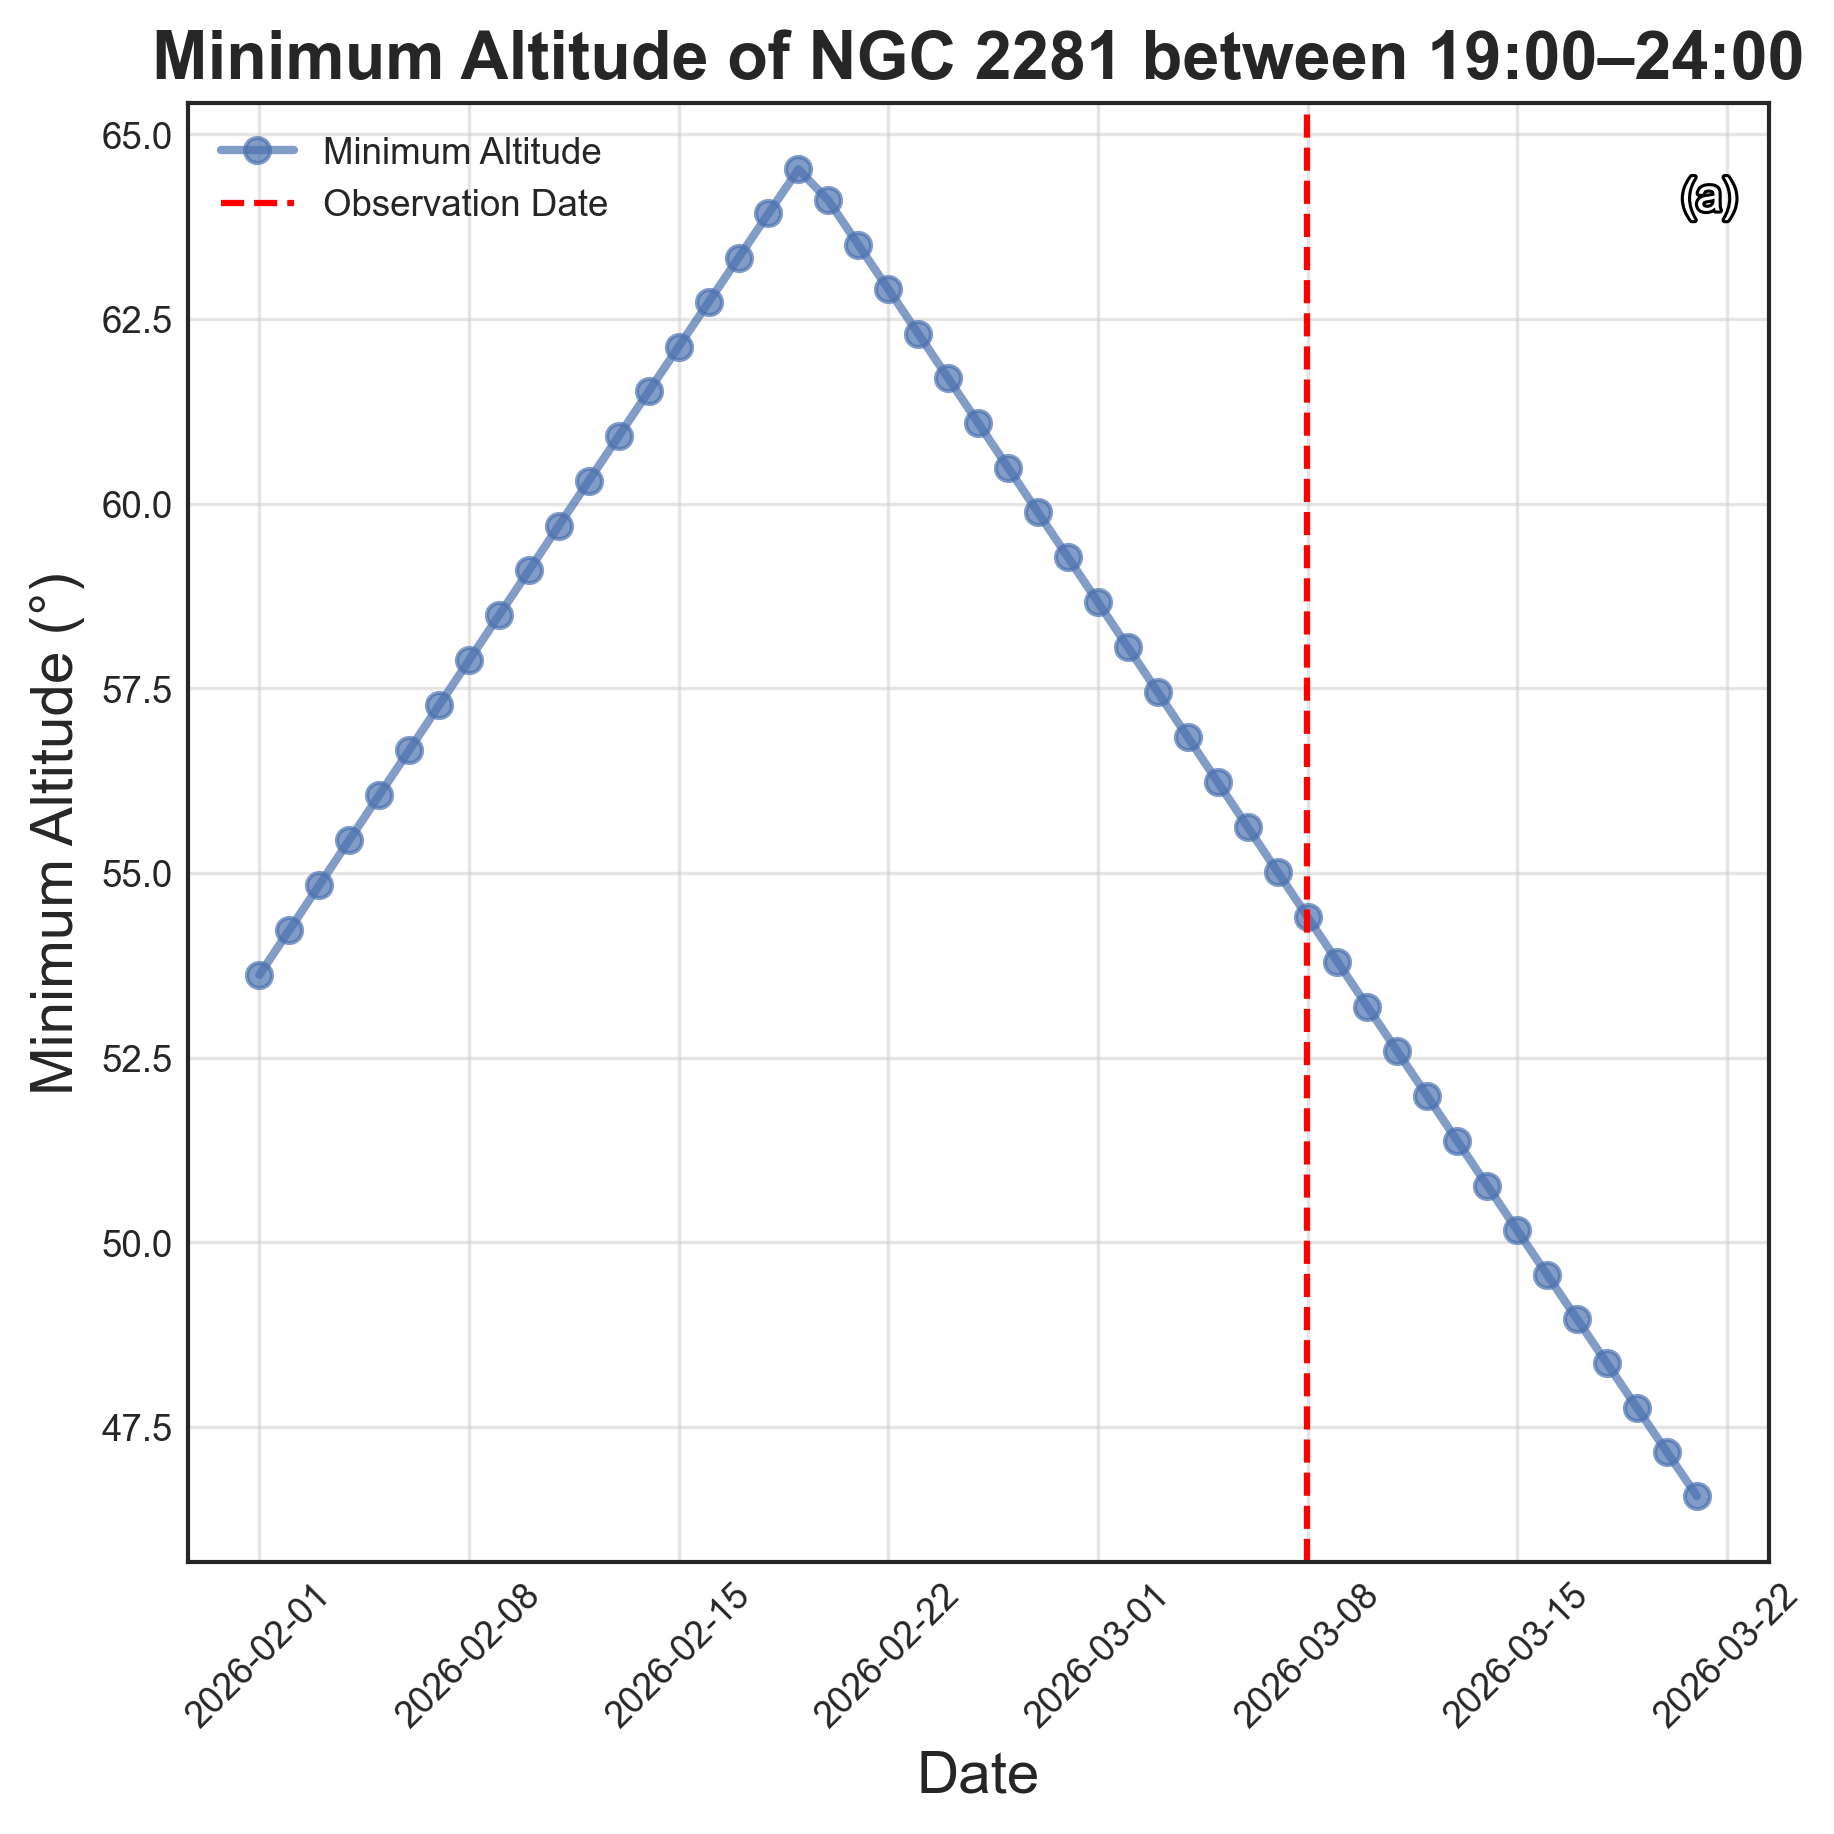

In [21]:
start_date = datetime(2026, 2, 1,  tzinfo=timezone)
end_date = datetime(2026, 3, 22,  tzinfo=timezone)
start_hour = 19
end_hour = 24

times = pd.date_range(
    start=start_date,
    end=end_date,
    freq="30min"
)
times = times[(times.hour >= start_hour) & (times.hour <= end_hour)]

frames = AltAz(obstime=times, location=observer.location, pressure=1010 * u.hPa)
ngc2281 = SkyCoord("06h48m16s", "+41d04m44s", frame="icrs").transform_to(frames)
altitudes = ngc2281.alt.degree

unique_dates = np.unique(times.date)
min_alt_per_day = [altitudes[times.date == d].min() for d in unique_dates]

fig, ax = plt.subplots(figsize=(6, 6), dpi=300, constrained_layout=True)

# Plot line with markers
ax.plot(
    unique_dates,
    min_alt_per_day,
    marker='o',
    linewidth=2,
    markersize=6,
    alpha=0.7,
    color='b',
    label="Minimum Altitude"
)

# Observation date vertical line
obs_date = datetime(2026, 3, 8, tzinfo=timezone)
ax.axvline(obs_date, color="red", linestyle='--', lw=1.5, label="Observation Date")

# Axis labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Minimum Altitude (°)", fontsize=14)
ax.set_title(
    f"Minimum Altitude of NGC 2281 between {start_hour}:00–{end_hour}:00",
    fontsize=16,
    weight='bold'
)

# Tick formatting
plt.xticks(rotation=45)
ax.tick_params(axis='both', which='both', length=0)
ax.minorticks_on()

# Grid
ax.grid(True)

# Legend
ax.legend(frameon=False)

# Annotation in corner (optional, like CMD/filters)
txt = ax.text(0.98, 0.95, "(a)", transform=ax.transAxes,
              fontsize=11, va="top", ha="right", color="white")
txt.set_path_effects([patheffects.withStroke(linewidth=1.5, foreground='black')])

# Save figure
plt.savefig("plots/NGC2281_altitude_date.png", dpi=300, bbox_inches='tight')
plt.show()

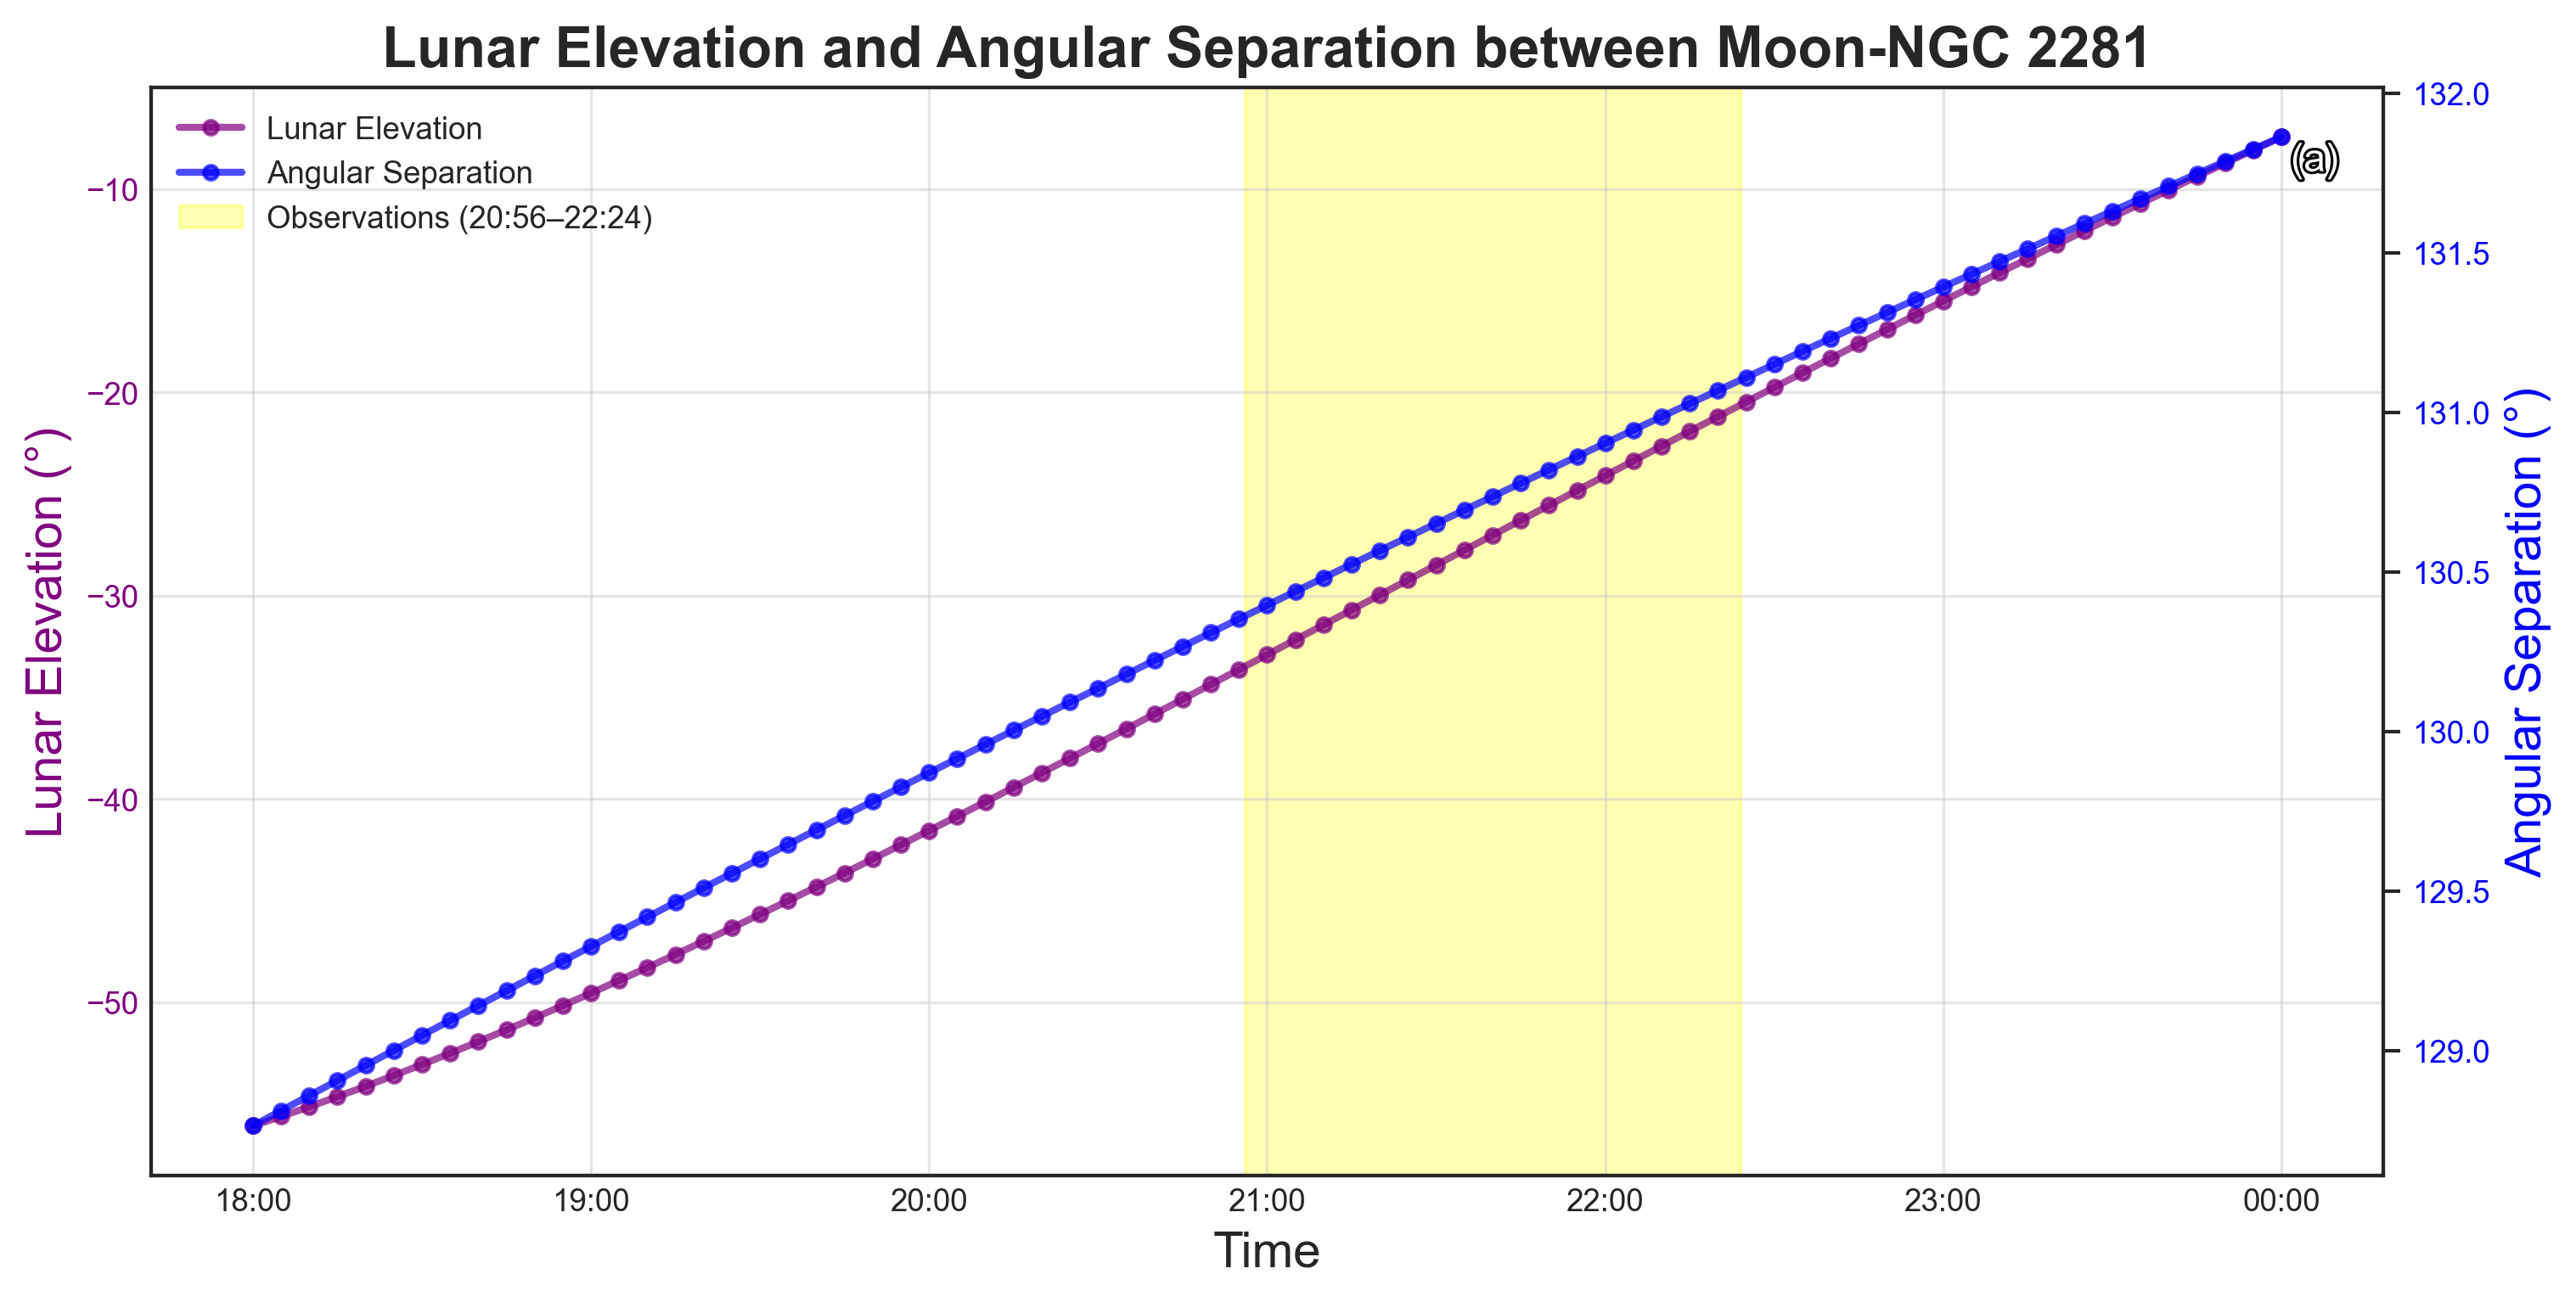

In [23]:
start_date = pd.Timestamp("2026-03-08 18:00:00", tz=timezone)
end_date   = pd.Timestamp("2026-03-09 00:00:00", tz=timezone)

obs_start = pd.Timestamp("2026-03-08 20:56:00", tz=timezone)
obs_end   = pd.Timestamp("2026-03-08 22:24:00", tz=timezone)

times = pd.date_range(start=start_date, end=end_date, freq="5min")

# --- Convert ONCE to Astropy time ---
times_utc = times.tz_convert("UTC")
times_astropy = Time(times_utc.to_numpy())
# --- AltAz frame ---
frame = AltAz(
    obstime=times_astropy,
    location=observer.location,
    pressure=1010 * u.hPa
)

# --- Target and Moon ---
ngc2281 = SkyCoord("06h48m16s", "+41d04m44s", frame="icrs").transform_to(frame)
moon = get_body('moon', times_astropy, location=observer.location).transform_to(frame)

moon_alt = moon.alt.deg
angular_sep = ngc2281.separation(moon).deg

# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(10, 5), dpi=300, constrained_layout=True)

# --- Lunar elevation ---
ax1.plot(
    times,
    moon_alt,
    color='purple',
    linewidth=2,
    marker='o',
    markersize=4,
    alpha=0.7,
    label="Lunar Elevation",
    zorder=5
)
ax1.set_ylabel("Lunar Elevation (°)", fontsize=14, color='purple')
ax1.tick_params(axis='y', labelcolor='purple')

# --- Observation window ---
ax1.axvspan(
    obs_start,
    obs_end,
    color='yellow',
    alpha=0.3,
    label='Observations (20:56–22:24)',
    zorder=0
)

# --- Angular separation ---
ax2 = ax1.twinx()
ax2.plot(
    times,
    angular_sep,
    color='blue',
    linewidth=2,
    marker='o',
    markersize=4,
    alpha=0.7,
    label="Angular Separation",
    zorder=5
)
ax2.set_ylabel("Angular Separation (°)", fontsize=14, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# --- X-axis formatting ---
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=timezone))
plt.xticks(rotation=45)

# --- Labels & title ---
ax1.set_xlabel("Time", fontsize=14)
ax1.set_title(
    "Lunar Elevation and Angular Separation between Moon-NGC 2281",
    fontsize=16,
    weight='bold'
)

# --- Merge legends ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Separate patches (for axvspan) from lines
pairs = list(zip(lines_1, labels_1))
patch = [(h, l) for h, l in pairs if isinstance(h, mpatches.Patch)]
line  = [(h, l) for h, l in pairs if not isinstance(h, mpatches.Patch)]

handles, labels = zip(*(line + list(zip(lines_2, labels_2)) + patch))
ax1.legend(handles, labels, loc='upper left', frameon=False)

# --- Grid ---
ax1.grid(True)
ax1.minorticks_on()
ax1.tick_params(axis='both', which='both', length=0)

# --- Corner annotation (optional) ---
txt = ax1.text(0.98, 0.95, "(a)", transform=ax1.transAxes,
               fontsize=11, va="top", ha="right", color="white")
txt.set_path_effects([patheffects.withStroke(linewidth=1.5, foreground='black')])

# --- Save figure ---
plt.savefig("plots/NGC2281_moon_sep_alt.png", dpi=300, bbox_inches='tight')
plt.show()

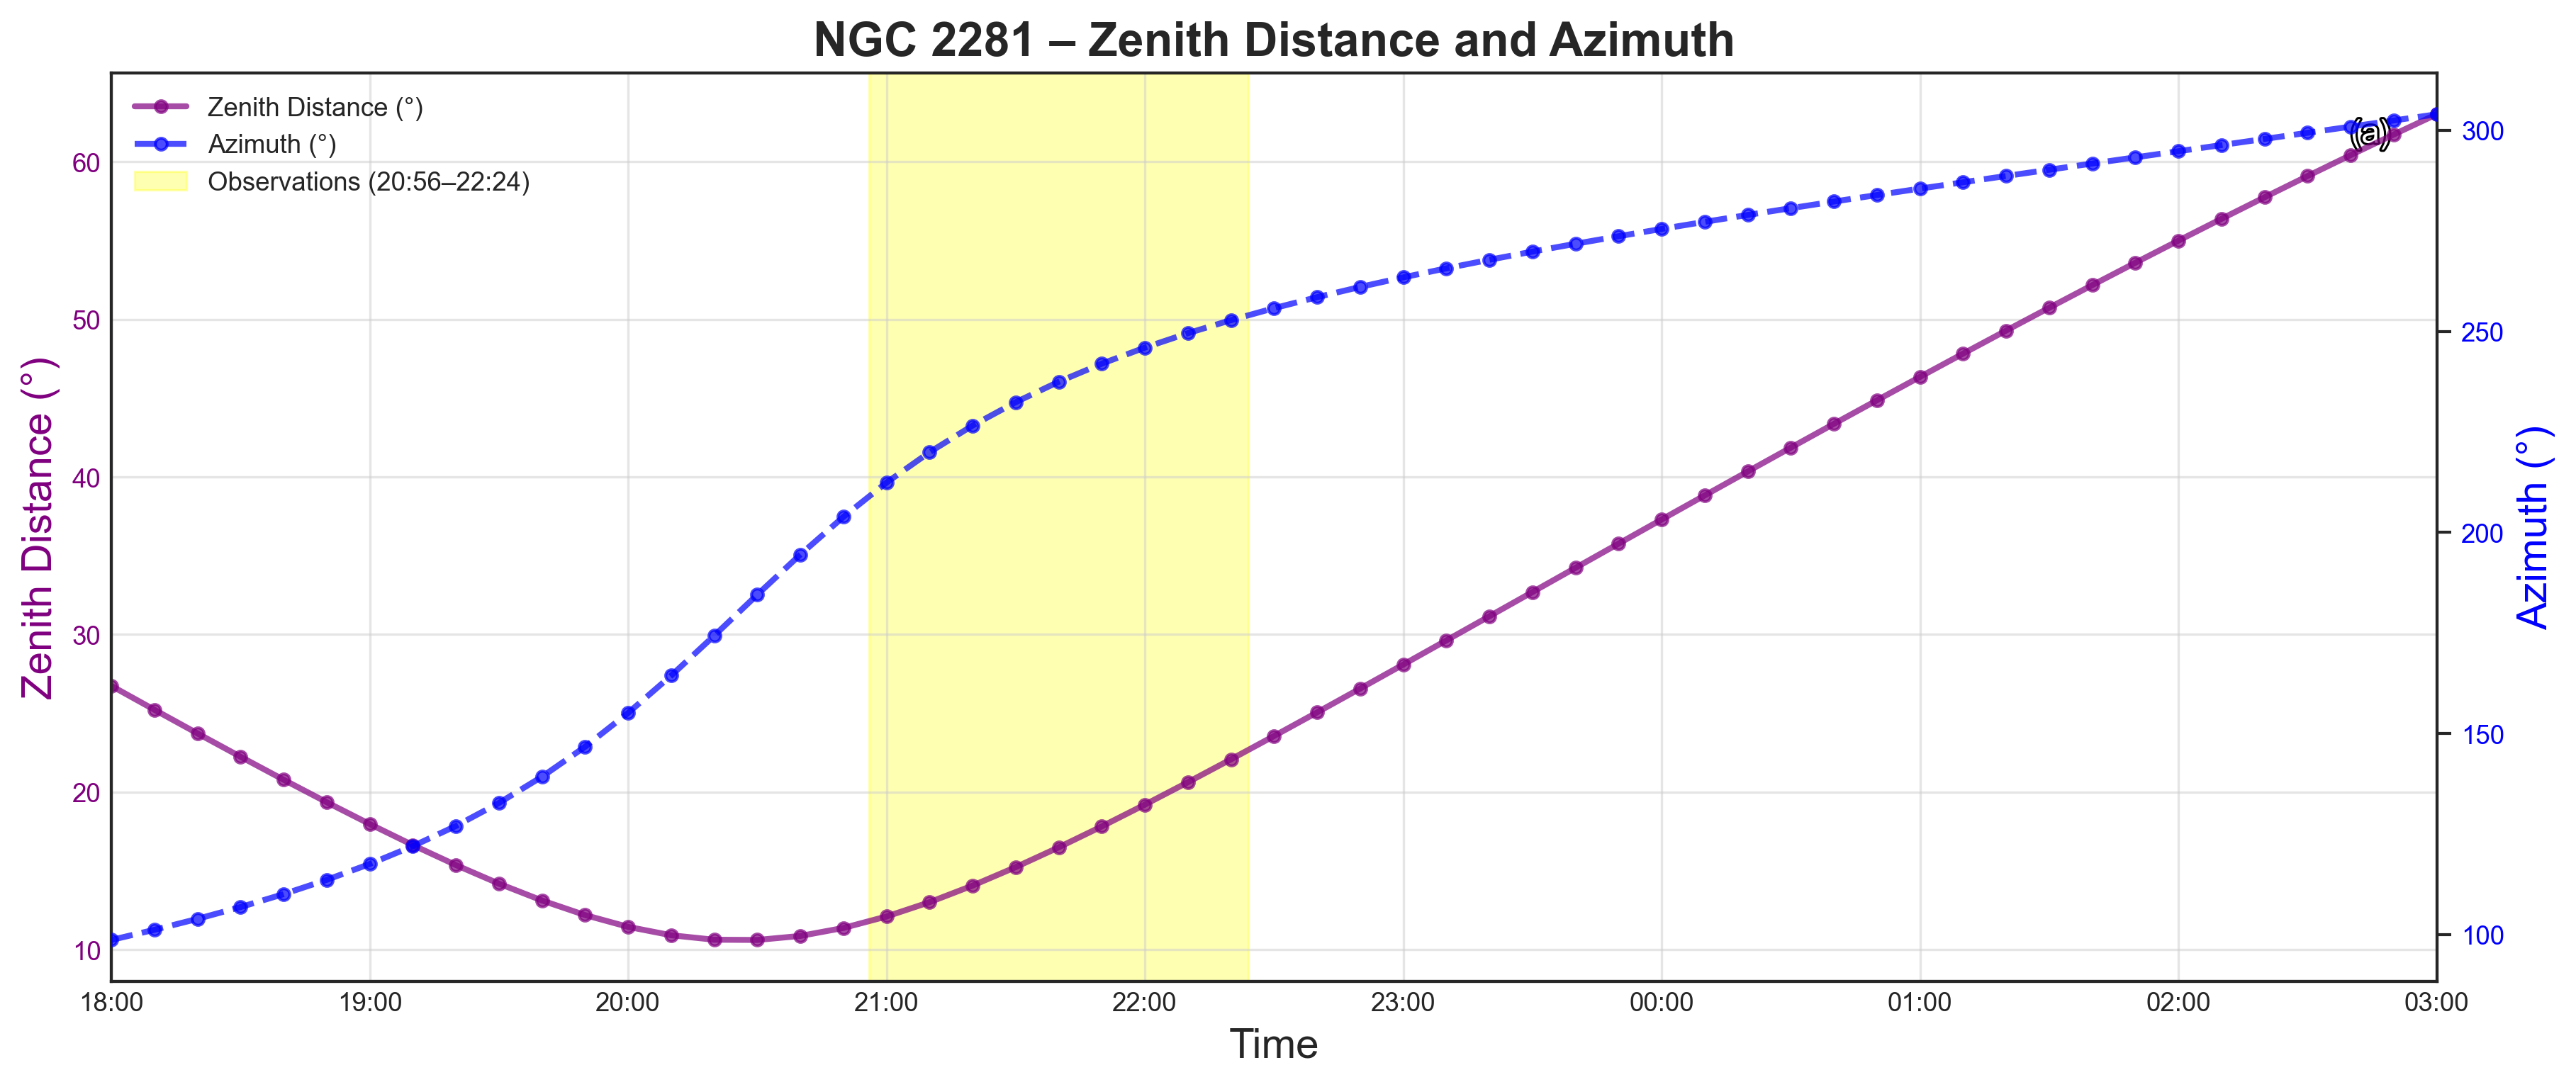

In [24]:
# -----------------------------
# NGC 2281 ZENITH DISTANCE + AZIMUTH
# -----------------------------

from astropy.coordinates import SkyCoord, AltAz, EarthLocation
from astropy.time import Time
import astropy.units as u
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import pytz
import matplotlib.patches as mpatches

# -----------------------------
# Observer
# -----------------------------
observer_location = EarthLocation(
    lat=52.1579 * u.deg,
    lon=5.388 * u.deg,
    height=12 * u.m
)

timezone = pytz.timezone("Europe/Amsterdam")

# -----------------------------
# Time (CONSISTENT WITH FIRST SCRIPT)
# -----------------------------
start_date = pd.Timestamp("2026-03-08 18:00:00", tz=timezone)
end_date   = pd.Timestamp("2026-03-09 03:00:00", tz=timezone)

times = pd.date_range(start=start_date, end=end_date, freq="10min")

# Convert ONCE to UTC → Astropy
times_utc = times.tz_convert("UTC")
times_astropy = Time(times_utc.to_numpy())

# -----------------------------
# Observation window
# -----------------------------
obs_start = pd.Timestamp("2026-03-08 20:56:00", tz=timezone)
obs_end   = pd.Timestamp("2026-03-08 22:24:00", tz=timezone)

# -----------------------------
# AltAz frame
# -----------------------------
frame = AltAz(
    obstime=times_astropy,
    location=observer_location,
    pressure=1010 * u.hPa
)

# -----------------------------
# Target
# -----------------------------
ngc2281 = SkyCoord(
    ra=102.825 * u.deg,
    dec=41.602 * u.deg,
    frame="icrs"
)

ngc2281_altaz = ngc2281.transform_to(frame)

alt = ngc2281_altaz.alt.deg
az  = ngc2281_altaz.az.deg

# -----------------------------
# Derived quantities
# -----------------------------
zenith_distance = 90 - alt
airmass = 1 / np.cos(np.radians(zenith_distance))  # optional

# -----------------------------
# Plot
# -----------------------------
fig, ax1 = plt.subplots(figsize=(12, 5), dpi=300, constrained_layout=True)

# --- Zenith distance ---
ax1.plot(
    times,
    zenith_distance,
    color='purple',
    linewidth=2,
    marker='o',
    markersize=4,
    alpha=0.7,
    label="Zenith Distance (°)",
    zorder=5
)
ax1.set_ylabel("Zenith Distance (°)", fontsize=14, color='purple')
ax1.tick_params(axis='y', labelcolor='purple')

# --- Observation window ---
ax1.axvspan(
    obs_start,
    obs_end,
    color='yellow',
    alpha=0.3,
    label='Observations (20:56–22:24)',
    zorder=0
)

# --- Azimuth (twin axis) ---
ax2 = ax1.twinx()
ax2.plot(
    times,
    az,
    color='blue',
    linewidth=2,
    linestyle='--',
    marker='o',
    markersize=4,
    alpha=0.7,
    label="Azimuth (°)",
    zorder=5
)
ax2.set_ylabel("Azimuth (°)", fontsize=14, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# --- X-axis formatting ---
xticks = pd.date_range(start_date, end_date, freq="1h")
ax1.set_xlim(start_date, end_date)
ax1.set_xticks(xticks)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=timezone))
plt.xticks(rotation=45)

# --- Labels & title ---
ax1.set_xlabel("Time", fontsize=14)
ax1.set_title(
    "NGC 2281 – Zenith Distance and Azimuth",
    fontsize=16,
    weight='bold'
)

# --- Merge legends ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Separate patches (for axvspan) from lines
pairs = list(zip(lines_1, labels_1))
patch = [(h, l) for h, l in pairs if isinstance(h, mpatches.Patch)]
line  = [(h, l) for h, l in pairs if not isinstance(h, mpatches.Patch)]

handles, labels = zip(*(line + list(zip(lines_2, labels_2)) + patch))
ax1.legend(handles, labels, loc='upper left', frameon=False)

# --- Grid & minor ticks ---
ax1.grid(True)
ax1.minorticks_on()
ax1.tick_params(axis='both', which='both', length=0)

# --- Corner annotation (optional) ---
txt = ax1.text(0.98, 0.95, "(a)", transform=ax1.transAxes,
               fontsize=11, va="top", ha="right", color="white")
txt.set_path_effects([patheffects.withStroke(linewidth=1.5, foreground='black')])

# --- Save figure ---
plt.savefig("plots/NGC2281_zenith_azimuth.png", dpi=300, bbox_inches='tight')
plt.show()